<a href="https://colab.research.google.com/github/Luis-GCH/Lab-PDI-Equipo-8/blob/Lab-PDI-Equipo-8/Pr%C3%A1ctica_3_Lab_PDI_Equipo_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Práctica 3: Clustering de una Imagen**

**Código**:

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

def cargar_imagen(ruta, redimensionar=True, size=(100, 100)):
    img = cv2.imread(ruta)
    if img is None:
        raise FileNotFoundError(f"No se pudo cargar la imagen: {ruta}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if redimensionar:
        img_rgb = cv2.resize(img_rgb, size)
    return img_rgb

def segmentar_imagen(img, k=2):
    pixel_vals = img.reshape((-1, 3))
    pixel_vals = np.float32(pixel_vals)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pixel_vals)

    labels = kmeans.labels_
    centers = np.uint8(kmeans.cluster_centers_)

    segmented_img = centers[labels.flatten()]
    segmented_img = segmented_img.reshape(img.shape)

    return segmented_img, centers, labels, pixel_vals

def mostrar_resultados_3d(pixel_vals, centers=None, k=0, title_suffix=""):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    sample_size = min(2000, len(pixel_vals))
    indices = np.random.choice(len(pixel_vals), sample_size, replace=False)
    sample_pixels = pixel_vals[indices] / 255.0

    ax.scatter(
        sample_pixels[:, 0],
        sample_pixels[:, 1],
        sample_pixels[:, 2],
        c=sample_pixels,
        marker="o",
        s=20,
        alpha=0.6,
        label="Píxeles",
    )

    if centers is not None and len(centers) > 0:
        center_colors = centers / 255.0
        ax.scatter(
            center_colors[:, 0],
            center_colors[:, 1],
            center_colors[:, 2],
            c=center_colors,
            marker="X",
            s=200,
            edgecolors="black",
            linewidth=2,
            label="Centros de Cluster",
        )

    ax.set_xlabel("Rojo")
    ax.set_ylabel("Verde")
    ax.set_zlabel("Azul")
    ax.set_title(f"Espacio RGB {title_suffix}")

    plt.legend()
    plt.tight_layout()
    plt.show()

def mostrar_comparacion_k(img_original, k_values):
    fig = plt.figure(figsize=(18, 6 * len(k_values)))

    for i, k in enumerate(k_values):
        segmented_img, centers, labels, pixel_vals = segmentar_imagen(img_original, k=k)

        if i == 0:
            ax1 = fig.add_subplot(len(k_values), 3, 1)
            ax1.imshow(img_original)
            ax1.set_title("Imagen Original")
            ax1.axis("off")

        ax2 = fig.add_subplot(len(k_values), 3, i * 3 + 2)
        ax2.imshow(segmented_img)
        ax2.set_title(f"Segmentada (k={k})")
        ax2.axis("off")

        ax3 = fig.add_subplot(len(k_values), 3, i * 3 + 3)
        colors = centers / 255.0
        ax3.imshow([colors], aspect="auto")
        ax3.set_title(f"Colores (k={k})")
        ax3.set_yticks([])
        ax3.set_xticks(range(k))
        ax3.set_xticklabels([f"C{i+1}" for i in range(k)])

        for j, color in enumerate(colors):
            r, g, b = color
            ax3.text(j, 0, f"R:{r:.2f}\nG:{g:.2f}\nB:{b:.2f}",
                    ha="center", va="top", fontsize=8,
                    color="white" if np.mean(color) < 0.5 else "black")

    plt.tight_layout()
    plt.show()

    for k in k_values:
        _, centers, _, pixel_vals = segmentar_imagen(img_original, k=k)
        mostrar_resultados_3d(pixel_vals, centers, k, f"(k={k})")

# --- EJECUCIÓN ---
ruta_imagen = "Imagen2.png"

try:
    print("Ejercicio 1: Visualización inicial")
    img_rgb = cargar_imagen(ruta_imagen)

    pixel_vals = img_rgb.reshape((-1, 3))
    pixel_vals = np.float32(pixel_vals)

    plt.imshow(img_rgb)
    plt.title("Imagen Original")
    plt.axis("off")
    plt.show()

    mostrar_resultados_3d(pixel_vals, None, 0, "(Sin clusters)")

    print("\nEjercicio 2: Comparativa de K")
    mostrar_comparacion_k(img_rgb, [2, 4, 6])

    print("\nEjercicio 3: Aplicación Práctica")
    k_practica = 15
    segmented_img, centers, labels, pixel_vals = segmentar_imagen(img_rgb, k=k_practica)

    plt.imshow(segmented_img)
    plt.title(f"Segmentación Detallada (k={k_practica})")
    plt.axis("off")
    plt.show()

except FileNotFoundError as e:
    print(e)

**Resultado de ejecutar el código**

Ejercicio 1: Representación de la imagen en el espacio RGB


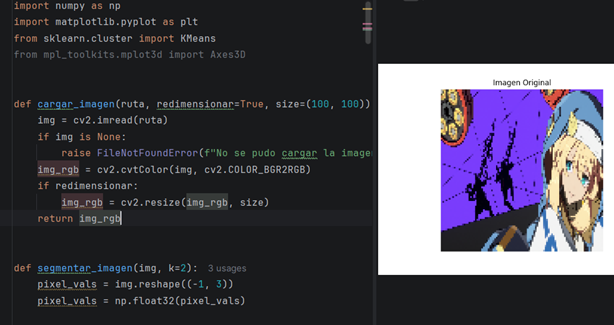

Ejercicio 2: Segmentación con K-mean

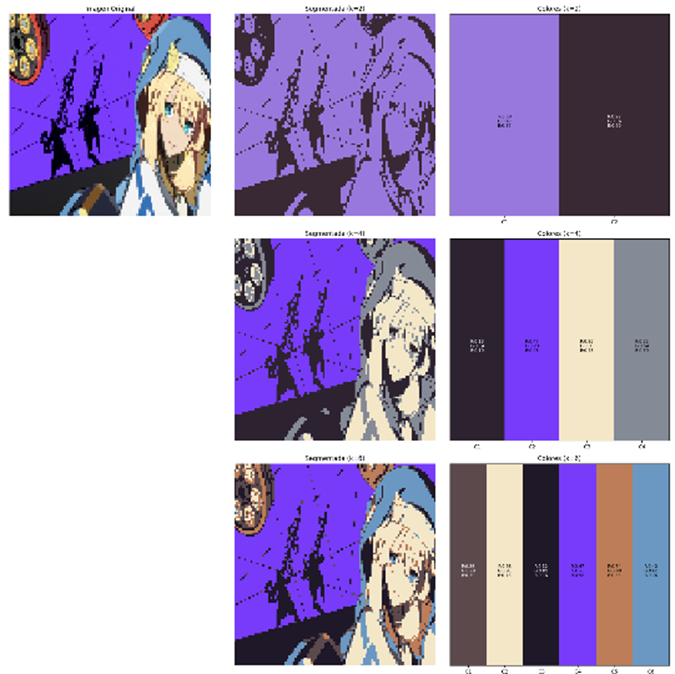

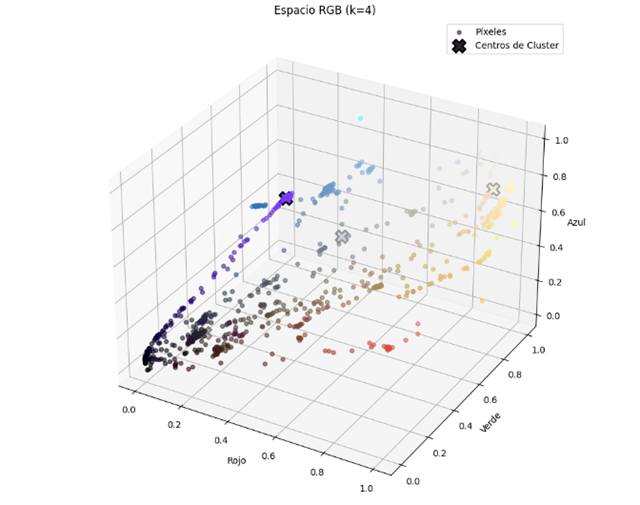

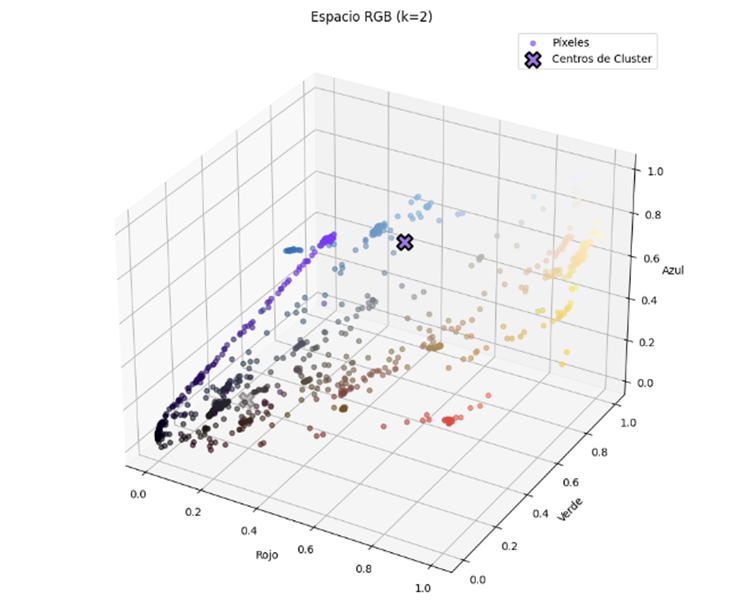

Ejercicio 3: Aplicación práctica - Segmentación para identificar regiones

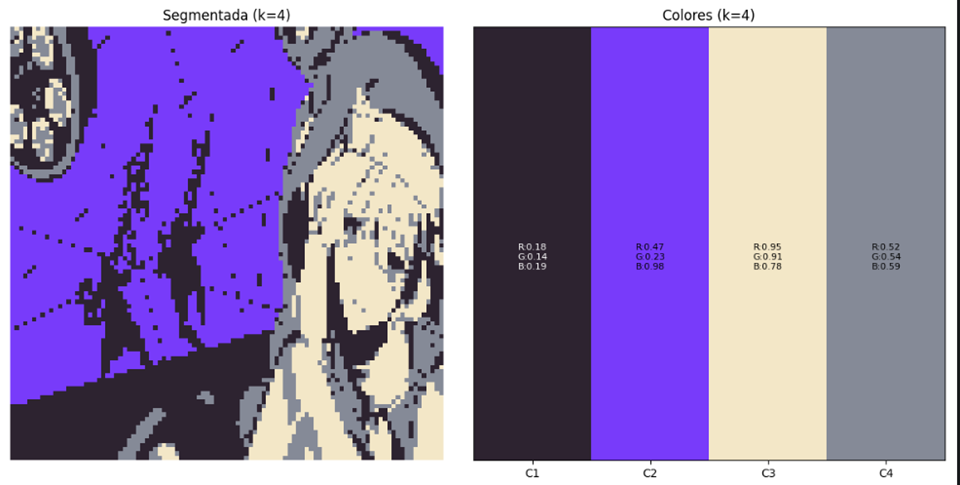

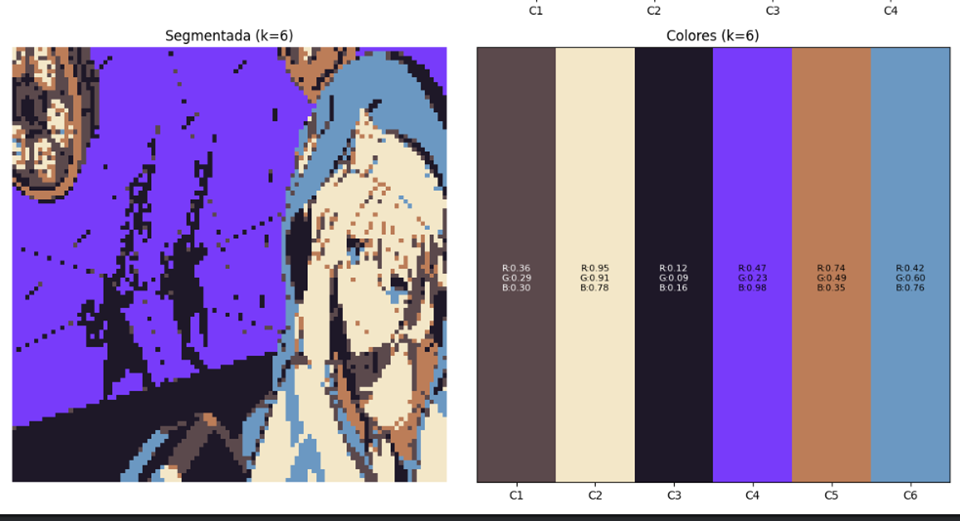


**Conclusión**

La práctica permitió aplicar el algoritmo K-means para segmentar imágenes según la similitud de sus colores, demostrando su eficacia como método de agrupamiento no supervisado. Se comprobó que al variar el número de clusters (k), cambia el nivel de detalle en la segmentación: valores bajos simplifican la imagen, mientras que valores altos generan una mayor precisión pero también posibles sobresegmentaciones.
En general, el ejercicio facilitó la comprensión de cómo K-means puede utilizarse para dividir una imagen en regiones cromáticas homogéneas, siendo una técnica útil en aplicaciones de visión por computadora y procesamiento biomédico de imágenes.
